# Brain Tumor MRI Classification Using EfficientNet-B3 and Data Augmentation

## Project Overview

**Objective:** Build a 4-class brain MRI image classifier using PyTorch, data augmentation, and EfficientNet-B3 transfer learning.

### Key Features
- Load and analyze medical imaging datasets.
- Apply realistic data augmentation to the training images.
- Fine-tune a pretrained EfficientNet-B3 model.
- Train and evaluate a deep learning classifier.
- Interpret results responsibly in a healthcare context.

### Important Disclaimer
**This is an educational project, not a clinical diagnostic tool.** Medical AI requires rigorous validation, regulatory approval, and clinical oversight before real-world deployment.

## 1. Project Title & Learning Outcomes

# Brain Tumor Diagnosis Using MRI

### Project Title

**Brain Tumor MRI Classification using Data Augmentation and Transfer Learning with EfficientNet-B3**

This is a four-class brain MRI image classifier using PyTorch. The model will learn to classify MRI images into:

1. Glioma
2. Meningioma
3. Pituitary
4. No Tumor

The dataset contains MRI images organized into training and testing folders.

### Student Learning Outcomes

By the end of this notebook, students should be able to:

- Explain the purpose of medical image classification.
- Load an image dataset using `torchvision.datasets.ImageFolder`.
- Inspect class distributions and recognize possible class imbalance.
- Apply resizing, normalization, and data augmentation.
- Use transfer learning with a pretrained EfficientNet-B3 model.
- Train a PyTorch model using a clean training loop.
- Evaluate a classifier using accuracy, precision, recall, F1 score, and a confusion matrix.
- Save, reload, and use a trained model for single-image prediction.

### Expected Skills Gained

Students will practice:

- PyTorch tensor and model workflows.
- Computer vision dataset preparation.
- Data augmentation for medical image classification.
- Transfer learning for limited-domain image data.
- Model evaluation and error analysis.
- Responsible interpretation of AI results in a healthcare context.

### Overview of Brain Tumor Detection

Brain tumor detection from MRI scans is an important medical imaging task. In this notebook, we are not building a clinical diagnostic system. Instead, we are building an educational classifier that demonstrates how deep learning can learn visual patterns associated with tumor categories and non-tumor scans.

Medical AI systems should support, not replace, trained clinicians. Real-world deployment requires strict validation, regulatory review, clinical oversight, privacy safeguards, and careful handling of uncertainty.

## 2. Problem Statement

# 2. Problem Statement

Brain tumor classification is the task of assigning a brain MRI image to a clinically meaningful category. In this project, the categories are glioma, meningioma, pituitary tumor, and no tumor.

MRI, or Magnetic Resonance Imaging, is widely used for brain imaging because it provides high-contrast views of soft tissue without ionizing radiation. This makes MRI especially useful for visualizing abnormalities in the brain.

Automated diagnosis is important because medical imaging workloads can be high, radiologists must review many scans, and subtle abnormalities may be difficult to distinguish. A computer vision model can help prioritize cases, provide a second opinion, and support consistent screening when used responsibly.

Radiologists face several challenges:

- Tumors may have similar appearances across categories.
- MRI images can vary by scanner, protocol, contrast, resolution, and patient positioning.
- Small abnormalities may be difficult to detect.
- Human fatigue and workload pressure can affect review speed.

The clinical significance is clear: earlier detection and accurate classification can help guide treatment planning, referral decisions, and follow-up care. However, a model trained in a notebook is only a learning artifact until it has been validated in a real clinical setting.


## 3. Motivation for Deep Learning

# 3. Motivation

Deep learning has become a powerful tool for medical image analysis because convolutional neural networks can learn hierarchical visual features directly from image pixels.

In healthcare, AI-assisted image classification may help with:

- Screening and triage.
- Decision support for clinicians.
- Reducing repetitive review burden.
- Highlighting cases that require closer attention.

Early detection matters because brain tumors can affect neurological function, treatment options, and patient outcomes. A fast automated classifier could support earlier review, especially in settings with limited specialist availability.

Deep learning is suitable for this task because MRI images contain complex spatial patterns. Traditional hand-crafted image features may miss subtle texture, shape, and intensity relationships. A pretrained deep model can reuse general visual features and adapt them to MRI classification through transfer learning.


## 4. Dataset Understanding

# 4. Dataset Understanding

Before training any model, we need to understand the dataset. Good machine learning begins with careful data inspection.

This notebook assumes the dataset is organized as:

```text
Brain_Tumor_MRI_Dataset/
├── train/
│   ├── Glioma/
│   ├── Meningioma/
│   ├── Pituitary/
│   └── No_Tumor/
├── test/
│   ├── Glioma/
│   ├── Meningioma/
│   ├── Pituitary/
│   └── No_Tumor/
```

The folder names are important because `ImageFolder` uses them as class labels.

The dataset has four classes and a total expected size of 12,064 images:

| Split | Glioma | Meningioma | Pituitary | No Tumor |
|---|---:|---:|---:|---:|
| Train | 3018 | 2183 | 2504 | 1945 |
| Test | 755 | 626 | 546 | 487 |

This distribution is not perfectly balanced. Class imbalance can cause a model to favor larger classes, so we will monitor performance using more than accuracy.

MRI images may differ in orientation, brightness, contrast, and anatomical appearance. These variations are one reason that preprocessing and augmentation are useful.


## Set the Dataset Path

The next code cell contains the **only value you should need to edit**: `DATASET_DIR`.

Use one of these locations depending on your operating system:

- Windows example: `r"C:\Users\YOUR_USERNAME\Desktop\Brain_Tumor_MRI_Dataset"`
- Mac/Linux example: `"~/Desktop/Brain_Tumor_MRI_Dataset"`

The default below uses the Desktop folder of the current user.


In [4]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [5]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from pathlib import Path

In [6]:
import zipfile
from pathlib import Path

zip_file = Path("Epic and CSCR hospital Dataset.zip")
extract_dir = Path("Epic_and_CSCR_Dataset")

with zipfile.ZipFile(zip_file, "r") as zip_ref:
    zip_ref.extractall(extract_dir)

print("Extraction completed.")

Extraction completed.


In [7]:
from pathlib import Path

for p in Path(".").rglob("*"):
    if p.is_dir():
        subdirs = [x.name.lower() for x in p.iterdir() if x.is_dir()]

        if "train" in subdirs and "test" in subdirs:
            print("DATASET ROOT FOUND:")
            print(p)

DATASET ROOT FOUND:
Epic_and_CSCR_Dataset/Epic and CSCR hospital Dataset
DATASET ROOT FOUND:
data/DeepPCB.v5i.yolov8


In [8]:
DATASET_DIR = Path("Epic_and_CSCR_Dataset/Epic and CSCR hospital Dataset")

TRAIN_DIR = DATASET_DIR / "Train"
TEST_DIR = DATASET_DIR / "Test"

print("Train Exists :", TRAIN_DIR.exists())
print("Test Exists  :", TEST_DIR.exists())

Train Exists : True
Test Exists  : True


In [9]:
EXPECTED_CLASSES = sorted(
    [folder.name for folder in TRAIN_DIR.iterdir() if folder.is_dir()]
)

print("Detected Classes:")
for cls in EXPECTED_CLASSES:
    print(cls)

Detected Classes:
glioma
meningioma
notumor
pituitary


In [10]:
def validate_dataset_structure(dataset_dir, class_names):

    print("=" * 60)
    print("DATASET VALIDATION")
    print("=" * 60)

    missing_paths = []

    if not dataset_dir.exists():
        raise FileNotFoundError(
            f"Dataset folder not found:\n{dataset_dir}"
        )

    for split_name in ["Train", "Test"]:

        split_dir = dataset_dir / split_name

        if not split_dir.exists():
            missing_paths.append(split_dir)
            continue

        for class_name in class_names:

            class_dir = split_dir / class_name

            if not class_dir.exists():
                missing_paths.append(class_dir)

    if missing_paths:

        error_msg = (
            "\nThe following required folders were not found:\n\n"
            + "\n".join(str(p) for p in missing_paths)
        )

        raise FileNotFoundError(error_msg)

    print("✓ Dataset folder found")
    print("✓ Train folder found")
    print("✓ Test folder found")
    print("✓ All class folders found")


def find_image_files(folder):

    return [
        path
        for path in folder.rglob("*")
        if path.is_file()
        and path.suffix.lower() in IMAGE_EXTENSIONS
    ]


def count_images_by_class(split_dir, class_names):

    counts = {}

    for class_name in class_names:

        class_dir = split_dir / class_name

        counts[class_name] = len(
            find_image_files(class_dir)
        )

    return counts


validate_dataset_structure(
    DATASET_DIR, EXPECTED_CLASSES
)

print("\nDataset structure looks correct.")

DATASET VALIDATION
✓ Dataset folder found
✓ Train folder found
✓ Test folder found
✓ All class folders found

Dataset structure looks correct.


In [11]:
IMAGE_EXTENSIONS = {
    ".jpg", ".jpeg", ".png",
    ".bmp", ".tif", ".tiff", ".webp"
}

def find_image_files(folder):
    return [
        p for p in folder.rglob("*")
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    ]

def count_images_by_class(split_dir, class_names):
    counts = {}

    for cls in class_names:
        counts[cls] = len(
            find_image_files(split_dir / cls)
        )

    return counts

print("Dataset structure verified.")

Dataset structure verified.


In [12]:
import pandas as pd

train_counts = count_images_by_class(
    TRAIN_DIR,
    EXPECTED_CLASSES
)

test_counts = count_images_by_class(
    TEST_DIR,
    EXPECTED_CLASSES
)

summary_df = pd.DataFrame({
    "Train": train_counts,
    "Test": test_counts
})

summary_df["Total"] = (
    summary_df["Train"] +
    summary_df["Test"]
)

display(summary_df)

print("\nTotal Images:",
      summary_df["Total"].sum())

,Train,Test,Total
glioma,3018,755,3773
meningioma,2183,546,2729
notumor,1945,487,2432
pituitary,2504,626,3130



Total Images: 12064


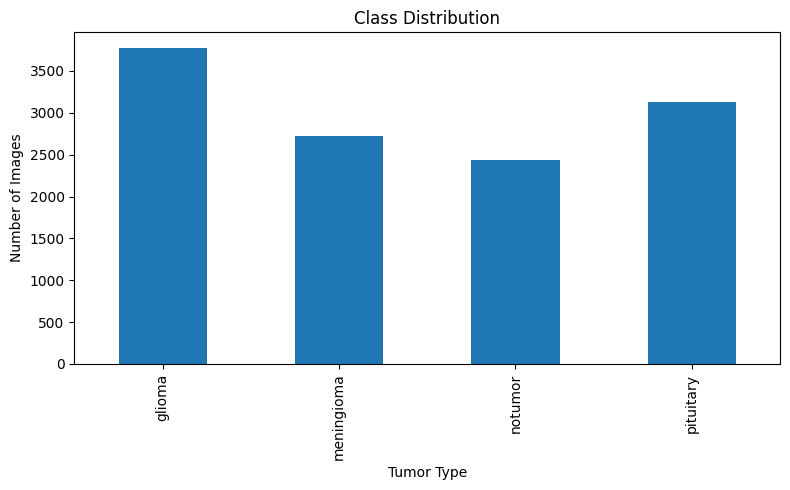

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

summary_df["Total"].plot(
    kind="bar"
)

plt.title("Class Distribution")
plt.xlabel("Tumor Type")
plt.ylabel("Number of Images")

plt.tight_layout()
plt.show()

## 5. Environment Setup

# 5. Environment Setup

This section imports the libraries needed for PyTorch model training and evaluation.

We also set a random seed. A seed makes the notebook more reproducible by controlling random operations such as data splitting and augmentation randomness.

The device selection code automatically uses a GPU if one is available:

- `cuda` for NVIDIA GPUs.
- `mps` for Apple Silicon GPUs.
- `cpu` if no supported GPU is available.


In [14]:
import random
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset

from torchvision import datasets, models, transforms

from tqdm.auto import tqdm

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)


SEED = 42
MODEL_VARIANT = "efficientnet_b3"
MODEL_DISPLAY_NAME = "EfficientNet-B3"
BATCH_SIZE = 16
IMAGE_SIZE = 300
NUM_EPOCHS = 10
LEARNING_RATE = 0.0001
VALIDATION_SPLIT = 0.15
NUM_WORKERS = 0
MODEL_SAVE_PATH = Path(f"best_brain_tumor_{MODEL_VARIANT}.pth")


def set_seed(seed):
    # Make common random operations more reproducible.
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # These settings improve reproducibility on CUDA.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Using device:", device)
print("Model variant:", MODEL_DISPLAY_NAME)
print("Input image size:", IMAGE_SIZE)
print("Batch size:", BATCH_SIZE)
print("Model save path:", MODEL_SAVE_PATH)

Using device: cuda
Model variant: EfficientNet-B3
Input image size: 300
Batch size: 16
Model save path: best_brain_tumor_efficientnet_b3.pth


## 6. Data Loading

# 6. Data Loading

PyTorch provides `torchvision.datasets.ImageFolder`, which is ideal when image data is stored in class-specific folders.

For example:

```text
train/Glioma/image_001.jpg
train/Meningioma/image_002.jpg
```

`ImageFolder` automatically:

1. Reads each subfolder as a class name.
2. Assigns each class an integer label.
3. Returns image-label pairs.

In this first loading step, we use a simple preview transform so images can be batched and visualized. Later, we will build the final training and evaluation datasets with full preprocessing.


In [15]:
# A simple transform for previewing images before final preprocessing.
preview_transform = transforms.Compose(
    [
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
    ]
)

# ImageFolder reads labels from class folder names.
train_preview_dataset = datasets.ImageFolder(
    root=TRAIN_DIR,
    transform=preview_transform,
)

test_preview_dataset = datasets.ImageFolder(
    root=TEST_DIR,
    transform=preview_transform,
)

# Confirm that train and test splits use the same label mapping.
if train_preview_dataset.class_to_idx != test_preview_dataset.class_to_idx:
    raise ValueError("Train and test class-to-index mappings do not match.")

class_names = train_preview_dataset.classes
class_to_idx = train_preview_dataset.class_to_idx
idx_to_class = {idx: name for name, idx in class_to_idx.items()}
NUM_CLASSES = len(class_names)

print("Class names:", class_names)
print("Class-to-index mapping:", class_to_idx)
print("Number of training images:", len(train_preview_dataset))
print("Number of testing images:", len(test_preview_dataset))


Class names: ['glioma', 'meningioma', 'notumor', 'pituitary']
Class-to-index mapping: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}
Number of training images: 9650
Number of testing images: 2414


In [16]:
# DataLoaders create mini-batches for efficient iteration.
train_preview_loader = DataLoader(
    train_preview_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
)

test_preview_loader = DataLoader(
    test_preview_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
)

images, labels = next(iter(train_preview_loader))
print("Batch image tensor shape:", images.shape)
print("Batch label tensor shape:", labels.shape)


Batch image tensor shape: torch.Size([16, 3, 300, 300])
Batch label tensor shape: torch.Size([16])


## 7. Data Visualization

# 7. Data Visualization

Visualization is a critical step in computer vision. Before training, we should inspect random samples to confirm that:

- Images are loading correctly.
- Labels match the visible image content.
- The dataset contains the expected classes.
- There are no obvious corrupt or misplaced images.

The first visualization shows a random mini-batch. The second visualization shows several samples from each class.


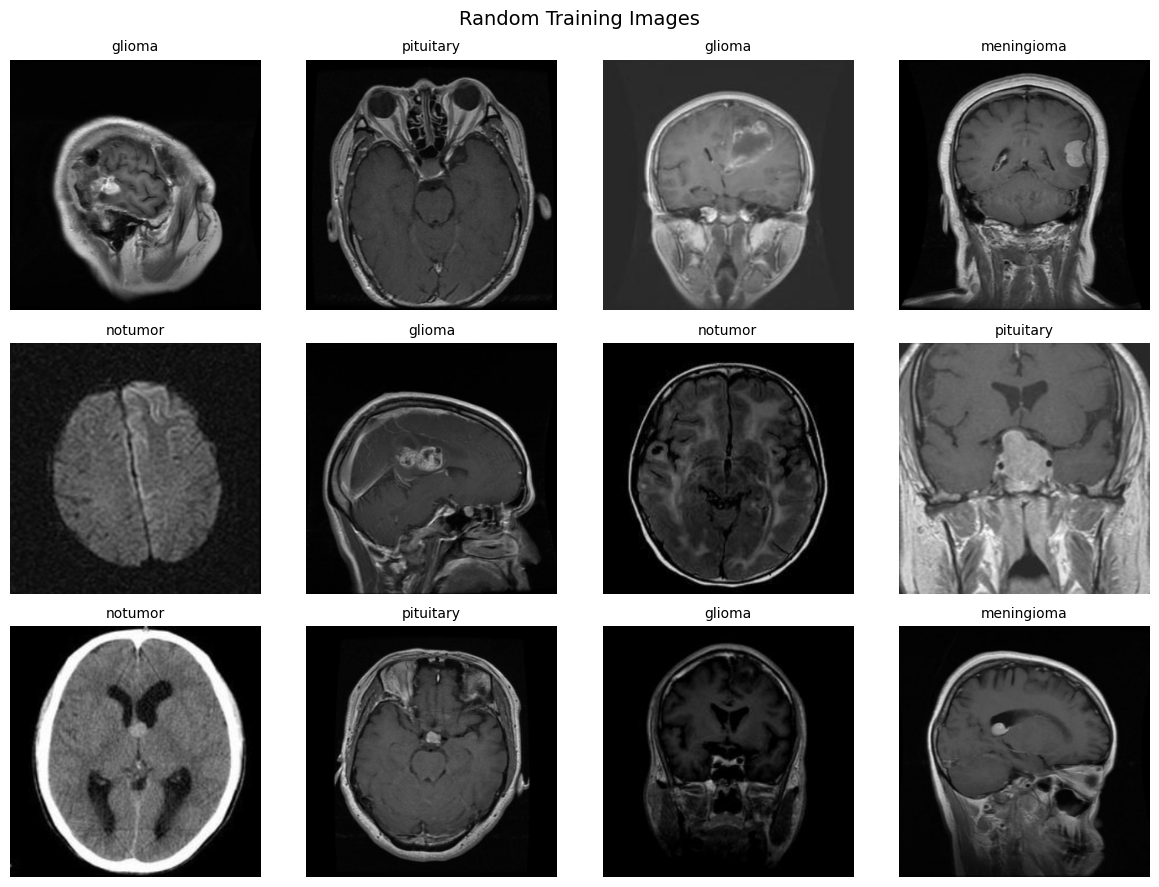

In [17]:
def show_image_tensor(image_tensor, ax, title=None):
    # Display a tensor image with shape [C, H, W].
    image = image_tensor.permute(1, 2, 0).numpy()
    ax.imshow(image)
    ax.axis("off")

    if title is not None:
        ax.set_title(title, fontsize=10)


images, labels = next(iter(train_preview_loader))
num_images_to_show = min(12, len(images))

fig, axes = plt.subplots(3, 4, figsize=(12, 9))
axes = axes.flatten()

for i in range(num_images_to_show):
    label_name = idx_to_class[labels[i].item()]
    show_image_tensor(images[i], axes[i], title=label_name)

for i in range(num_images_to_show, len(axes)):
    axes[i].axis("off")

plt.suptitle("Random Training Images", fontsize=14)
plt.tight_layout()
plt.show()


## 8. Data Preprocessing and Augmentation

# 8. Data Preprocessing and Augmentation

Preprocessing prepares images for the neural network, and augmentation creates realistic variations of the training images so the model is less sensitive to small differences in scan appearance.

We will use:

- **Resize/crop to 300 x 300**: this notebook uses the input size selected for EfficientNet-B3.
- **Normalization**: pretrained ImageNet models expect inputs normalized with ImageNet mean and standard deviation.
- **Data augmentation for training only**: random transformations help the model generalize beyond the exact images it sees during training.

Training augmentations used here:

- `RandomResizedCrop`
- `RandomHorizontalFlip`
- `RandomRotation`
- `RandomAffine`
- `ColorJitter`
- Light `GaussianBlur`

Validation and testing data should not use random augmentation. Evaluation should measure performance on stable, consistently processed images.

In [18]:
# ImageNet normalization values used by torchvision pretrained models.
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

AUGMENT_RESIZE_SIZE = int(IMAGE_SIZE * 1.15)

train_transform = transforms.Compose(
    [
        transforms.Resize((AUGMENT_RESIZE_SIZE, AUGMENT_RESIZE_SIZE)),
        transforms.RandomResizedCrop(
            size=(IMAGE_SIZE, IMAGE_SIZE),
            scale=(0.85, 1.0),
            ratio=(0.95, 1.05),
        ),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=12),
        transforms.RandomAffine(
            degrees=0,
            translate=(0.04, 0.04),
            scale=(0.95, 1.05),
        ),
        transforms.ColorJitter(brightness=0.18, contrast=0.18),
        transforms.RandomApply(
            [transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0))],
            p=0.10,
        ),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ]
)

eval_transform = transforms.Compose(
    [
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ]
)

In [19]:
# Create separate datasets so validation uses deterministic preprocessing.
train_dataset_augmented = datasets.ImageFolder(
    root=TRAIN_DIR,
    transform=train_transform,
)

train_dataset_for_validation = datasets.ImageFolder(
    root=TRAIN_DIR,
    transform=eval_transform,
)

test_dataset = datasets.ImageFolder(
    root=TEST_DIR,
    transform=eval_transform,
)

# Reuse the same class order discovered by ImageFolder.
if train_dataset_augmented.classes != class_names:
    raise ValueError("Training class order changed unexpectedly.")

if test_dataset.classes != class_names:
    raise ValueError("Testing class order does not match training class order.")


In [20]:
# Create a validation split from the training folder.
num_train_images = len(train_dataset_augmented)
num_val_images = int(num_train_images * VALIDATION_SPLIT)

generator = torch.Generator().manual_seed(SEED)
all_indices = torch.randperm(num_train_images, generator=generator).tolist()

val_indices = all_indices[:num_val_images]
train_indices = all_indices[num_val_images:]

train_dataset = Subset(train_dataset_augmented, train_indices)
val_dataset = Subset(train_dataset_for_validation, val_indices)

print(f"Training images used for training: {len(train_dataset):,}")
print(f"Training images held out for validation: {len(val_dataset):,}")
print(f"Testing images kept for final evaluation: {len(test_dataset):,}")


Training images used for training: 8,203
Training images held out for validation: 1,447
Testing images kept for final evaluation: 2,414


In [21]:
pin_memory = device.type == "cuda"

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory,
)

print("Final DataLoaders are ready.")


Final DataLoaders are ready.


## 9. Model Selection

# 9. Model Selection Discussion

There are several reasonable model choices for this project.

| Model | Advantages | Disadvantages |
|---|---|---|
| Custom CNN | Easy to understand, small, fully controlled by the student | Usually needs more data and tuning to perform well |
| ResNet18 | Strong baseline, simple residual architecture, widely used | Less parameter-efficient than newer architectures |
| EfficientNet-B1 | Compact and efficient, stronger than B0 | May miss some detail compared with larger variants |
| EfficientNet-B2 | More capacity than B1 while still efficient | Higher memory and training cost |
| EfficientNet-B3 | Stronger feature extractor with larger image input | Slowest and most memory-heavy option in these labs |

## Why EfficientNet-B3?

EfficientNet-B3 is the largest model in this set. It can learn richer visual features, but it needs more memory and longer training time.

EfficientNet uses compound scaling to balance network depth, width, and input resolution. This lab applies EfficientNet-B3 with pretrained ImageNet weights, then replaces the classifier for the four brain MRI classes.

## 10. Model Architecture

# 10. Model Architecture

We will use transfer learning.

Transfer learning means starting from a model that has already learned useful visual features from a large dataset, then adapting it to a new task. Here, EfficientNet-B3 is pretrained on ImageNet. ImageNet images are not medical images, but the early layers still learn useful patterns such as edges, textures, and shapes.

The original EfficientNet-B3 classifier predicts 1,000 ImageNet classes. Our dataset has four classes, so we replace the final classifier layer with a new layer that outputs four logits.

A **logit** is a raw model score before softmax. During training, `CrossEntropyLoss` compares logits to the correct class labels.

In [22]:
def build_efficientnet_b3(num_classes):
    # Create a EfficientNet-B3 model adapted for this dataset.
    weights = models.EfficientNet_B3_Weights.DEFAULT

    # Load pretrained EfficientNet-B3 weights.
    model = models.efficientnet_b3(weights=weights)

    # Replace the final classification layer.
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, num_classes)

    return model


model = build_efficientnet_b3(num_classes=NUM_CLASSES)
model = model.to(device)
print(model)

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /home/zeus/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 123MB/s]


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 40, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(40, 40, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=40, bias=False)
            (1): BatchNorm2d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(40, 10, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(10, 40, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActiv

In [23]:
def summarize_model(model):
    # Print a compact model summary.
    total_params = sum(parameter.numel() for parameter in model.parameters())
    trainable_params = sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )

    print(f"Total parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")
    print("\nFinal classifier:")
    print(model.classifier)


summarize_model(model)


Total parameters: 10,702,380
Trainable parameters: 10,702,380

Final classifier:
Sequential(
  (0): Dropout(p=0.3, inplace=True)
  (1): Linear(in_features=1536, out_features=4, bias=True)
)


## 11. Training Strategy

# 11. Training Strategy

The model will be trained using the following strategy:

## Loss Function: Cross Entropy Loss

Cross entropy is commonly used for multi-class classification. It compares the model's predicted class scores with the true label.

## Optimizer: Adam

Adam adapts the learning rate for each parameter and usually works well as a default optimizer.

## Learning Rate

We use a small learning rate of `0.0001` because the model starts from pretrained weights. A smaller learning rate helps avoid damaging useful pretrained features too quickly.

## Epochs

We train for `10` epochs. One epoch means the model has seen the full training subset once.

## Validation Monitoring

We evaluate on a validation split after every epoch. The best validation model is saved as:

```text
best_brain_tumor_efficientnet_b3.pth
```

In [24]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

print("Loss function:", criterion)
print("Optimizer:", optimizer)


Loss function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
)


## 12. Training Loop

# 12. Training Loop

The training loop is the heart of the notebook.

For each batch, PyTorch performs these steps:

1. Move images and labels to the selected device.
2. Run the model forward to produce predictions.
3. Compute the loss.
4. Clear old gradients.
5. Backpropagate the loss.
6. Update model weights.
7. Track loss and accuracy.

The evaluation loop is similar, but it uses `torch.no_grad()` because we do not update model weights during validation or testing.


In [25]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    # Train the model for one epoch and return loss and accuracy.
    model.train()

    running_loss = 0.0
    correct_predictions = 0
    total_examples = 0

    progress_bar = tqdm(dataloader, desc="Training", leave=False)

    for images, labels in progress_bar:
        images = images.to(device)
        labels = labels.to(device)

        # Clear gradients from the previous step.
        optimizer.zero_grad()

        # Forward pass.
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass and parameter update.
        loss.backward()
        optimizer.step()

        # Update running metrics.
        batch_size = labels.size(0)
        running_loss += loss.item() * batch_size
        predictions = outputs.argmax(dim=1)
        correct_predictions += (predictions == labels).sum().item()
        total_examples += batch_size

        progress_bar.set_postfix(
            loss=running_loss / total_examples,
            accuracy=correct_predictions / total_examples,
        )

    epoch_loss = running_loss / total_examples
    epoch_accuracy = correct_predictions / total_examples

    return epoch_loss, epoch_accuracy


In [26]:
def evaluate_model(model, dataloader, criterion, device, desc="Evaluating"):
    # Evaluate the model and return loss, accuracy, true labels, and predictions.
    model.eval()

    running_loss = 0.0
    correct_predictions = 0
    total_examples = 0

    all_true_labels = []
    all_predicted_labels = []

    progress_bar = tqdm(dataloader, desc=desc, leave=False)

    with torch.no_grad():
        for images, labels in progress_bar:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            predictions = outputs.argmax(dim=1)

            batch_size = labels.size(0)
            running_loss += loss.item() * batch_size
            correct_predictions += (predictions == labels).sum().item()
            total_examples += batch_size

            all_true_labels.extend(labels.cpu().numpy())
            all_predicted_labels.extend(predictions.cpu().numpy())

            progress_bar.set_postfix(
                loss=running_loss / total_examples,
                accuracy=correct_predictions / total_examples,
            )

    epoch_loss = running_loss / total_examples
    epoch_accuracy = correct_predictions / total_examples

    return epoch_loss, epoch_accuracy, all_true_labels, all_predicted_labels


In [27]:
history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": [],
}

best_val_accuracy = -1.0

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch + 1}/{NUM_EPOCHS}")

    train_loss, train_accuracy = train_one_epoch(
        model=model,
        dataloader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
    )

    val_loss, val_accuracy, _, _ = evaluate_model(
        model=model,
        dataloader=val_loader,
        criterion=criterion,
        device=device,
        desc="Validation",
    )

    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_accuracy)

    print(
        f"Train Loss: {train_loss:.4f} | "
        f"Train Accuracy: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Accuracy: {val_accuracy:.4f}"
    )

    # Save the model whenever validation accuracy improves.
    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        print(f"Saved new best model to {MODEL_SAVE_PATH}")

print(f"\nBest validation accuracy: {best_val_accuracy:.4f}")



Epoch 1/10


Training:   0%|          | 0/513 [00:00<?, ?it/s]

Validation:   0%|          | 0/91 [00:00<?, ?it/s]

Train Loss: 0.3567 | Train Accuracy: 0.8827 | Val Loss: 0.0931 | Val Accuracy: 0.9696
Saved new best model to best_brain_tumor_efficientnet_b3.pth

Epoch 2/10


Training:   0%|          | 0/513 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/91 [00:00<?, ?it/s]

Train Loss: 0.0233 | Train Accuracy: 0.9929 | Val Loss: 0.0405 | Val Accuracy: 0.9889

Epoch 10/10


Training:   0%|          | 0/513 [00:00<?, ?it/s]

Validation:   0%|          | 0/91 [00:00<?, ?it/s]

Train Loss: 0.0171 | Train Accuracy: 0.9945 | Val Loss: 0.0512 | Val Accuracy: 0.9869

Best validation accuracy: 0.9917


## 13. Model Evaluation

# 13. Evaluation

After training, we evaluate the saved best model on the held-out test set.

We will calculate:

- **Test Accuracy**: the fraction of correctly classified images.
- **Precision**: among images predicted as a class, how many were correct.
- **Recall**: among images truly belonging to a class, how many were found.
- **F1 Score**: the harmonic mean of precision and recall.

Accuracy alone can be misleading when classes are imbalanced. Precision, recall, and F1 score provide a more complete view of model behavior.


In [28]:
# Load the best saved model before final testing.
loaded_model = build_efficientnet_b3(num_classes=NUM_CLASSES)
loaded_model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=device))
loaded_model = loaded_model.to(device)
loaded_model.eval()

print(f"Loaded saved model from: {MODEL_SAVE_PATH}")

Loaded saved model from: best_brain_tumor_efficientnet_b3.pth


In [29]:
test_loss, test_accuracy, y_true, y_pred = evaluate_model(
    model=loaded_model,
    dataloader=test_loader,
    criterion=criterion,
    device=device,
    desc="Testing",
)

precision = precision_score(y_true, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_true, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Weighted Precision: {precision:.4f}")
print(f"Weighted Recall: {recall:.4f}")
print(f"Weighted F1 Score: {f1:.4f}")


Testing:   0%|          | 0/151 [00:00<?, ?it/s]

Test Loss: 0.0688
Test Accuracy: 0.9801
Weighted Precision: 0.9802
Weighted Recall: 0.9801
Weighted F1 Score: 0.9801


In [30]:
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    zero_division=0,
)

print(report)


              precision    recall  f1-score   support

      glioma       0.98      0.97      0.97       755
  meningioma       0.95      0.97      0.96       546
     notumor       1.00      0.99      1.00       487
   pituitary       0.99      1.00      0.99       626

    accuracy                           0.98      2414
   macro avg       0.98      0.98      0.98      2414
weighted avg       0.98      0.98      0.98      2414



## 14. Confusion Matrix Analysis

# 14. Confusion Matrix

A confusion matrix shows where the model is correct and where it is confused.

Rows represent the true labels. Columns represent the predicted labels. The diagonal values are correct predictions. Off-diagonal values show mistakes.

For example, if many glioma images are predicted as meningioma, that may mean the model struggles to distinguish those visual patterns.


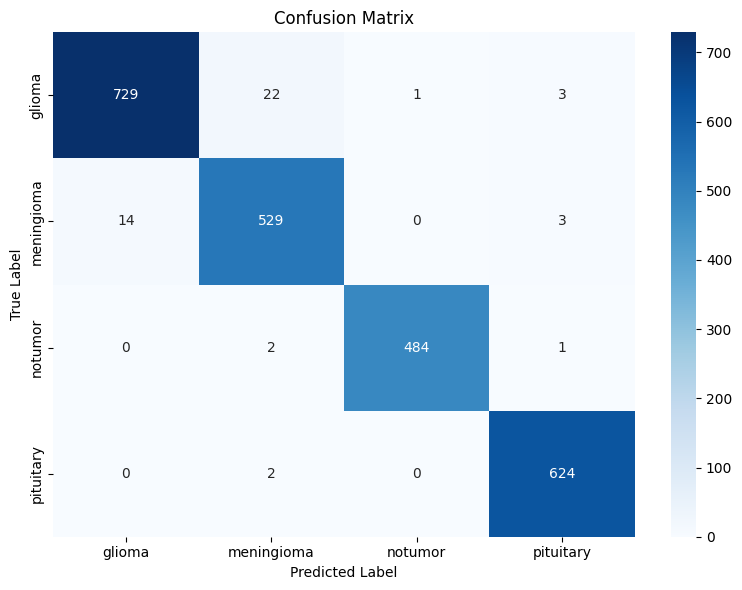

In [31]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


## 15. Training Curves

# 15. Training Curves

Training curves help diagnose learning behavior.

- If training loss decreases but validation loss increases, the model may be overfitting.
- If both training and validation accuracy remain low, the model may be underfitting.
- If validation accuracy improves steadily, training is likely progressing well.

The curves below plot loss and accuracy across epochs.


In [32]:
history_df = pd.DataFrame(history)
history_df.index = history_df.index + 1
history_df.index.name = "Epoch"
display(history_df)


,train_loss,train_accuracy,val_loss,val_accuracy
Epoch,,,,
1,0.356665,0.882726,0.093138,0.969592
2,0.110727,0.965257,0.046330,0.987560
3,0.063693,0.980129,0.044465,0.983414
4,0.044537,0.987687,0.041144,0.987560
5,0.033854,0.989272,0.036164,0.990325
6,0.022013,0.992442,0.038287,0.988252
7,0.017504,0.994392,0.028159,0.991707
8,0.016312,0.995002,0.055230,0.984796
9,0.023300,0.992929,0.040545,0.988943


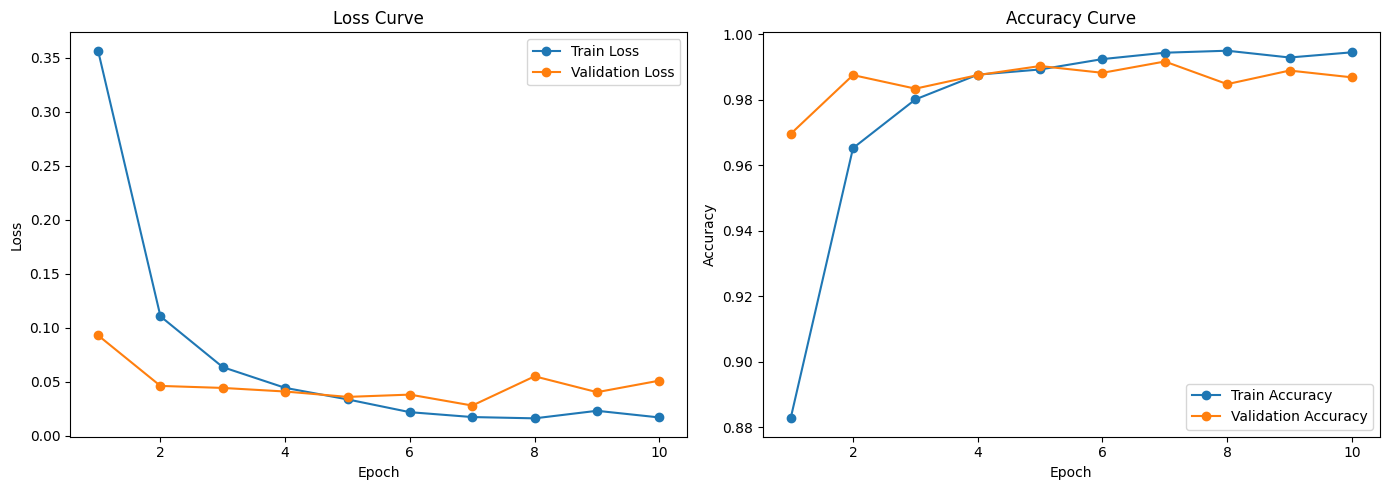

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_df.index, history_df["train_loss"], marker="o", label="Train Loss")
axes[0].plot(history_df.index, history_df["val_loss"], marker="o", label="Validation Loss")
axes[0].set_title("Loss Curve")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(
    history_df.index,
    history_df["train_accuracy"],
    marker="o",
    label="Train Accuracy",
)
axes[1].plot(
    history_df.index,
    history_df["val_accuracy"],
    marker="o",
    label="Validation Accuracy",
)
axes[1].set_title("Accuracy Curve")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()


## 16. Single Image Prediction

# 16. Prediction Demo

Now we will create a helper function called `predict_image(image_path)`.

The function will:

1. Load a single MRI image.
2. Apply the same preprocessing used for validation and testing.
3. Run the trained model.
4. Convert logits to confidence scores using softmax.
5. Display the image and confidence table.

This is the kind of function you might use in a small demo application. In real healthcare settings, predictions must be reviewed by qualified clinicians.


In [34]:
def predict_image(image_path, model=loaded_model):
    # Predict the class of one image and display confidence scores.
    image_path = Path(image_path)

    if not image_path.exists():
        raise FileNotFoundError(f"Image not found: {image_path}")

    image = Image.open(image_path).convert("RGB")

    # Apply evaluation preprocessing and add a batch dimension.
    input_tensor = eval_transform(image).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        logits = model(input_tensor)
        probabilities = torch.softmax(logits, dim=1).squeeze(0).cpu()

    predicted_index = probabilities.argmax().item()
    predicted_class = class_names[predicted_index]
    predicted_confidence = probabilities[predicted_index].item()

    confidence_df = pd.DataFrame(
        {
            "Class": class_names,
            "Confidence": probabilities.numpy(),
        }
    ).sort_values("Confidence", ascending=False)

    print(f"Image: {image_path}")
    print(f"Predicted class: {predicted_class}")
    print(f"Confidence: {predicted_confidence:.4f}")
    display(confidence_df)

    plt.figure(figsize=(5, 5))
    plt.imshow(image)
    plt.axis("off")
    plt.title(f"Prediction: {predicted_class} ({predicted_confidence:.2%})")
    plt.show()

    return predicted_class, confidence_df


Image: Epic_and_CSCR_Dataset/Epic and CSCR hospital Dataset/Test/glioma/G_6_VF_.jpg
Predicted class: glioma
Confidence: 0.9998


,Class,Confidence
0,glioma,9.998293e-01
1,meningioma,1.704461e-04
2,notumor,2.860521e-07
3,pituitary,2.078190e-08


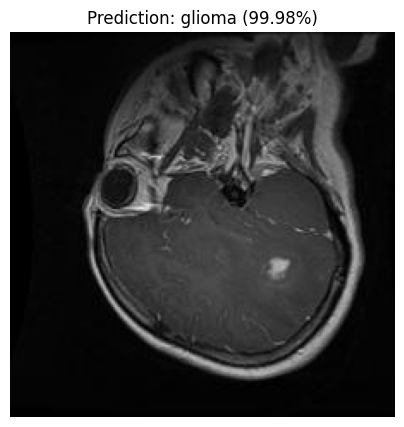

In [35]:
# Example usage:
# The notebook automatically selects the first available image from the test set.
example_image_path = None

for class_name in class_names:
    candidate_paths = find_image_files(TEST_DIR / class_name)
    if candidate_paths:
        example_image_path = candidate_paths[0]
        break

if example_image_path is not None:
    predict_image(example_image_path)
else:
    print("No test images were found for the prediction demo.")


## 17. Error Analysis

# 17. Error Analysis

Error analysis asks: **when the model is wrong, why might it be wrong?**

Possible reasons for mistakes include:

- Glioma, meningioma, and pituitary tumors can share visual patterns.
- Tumor shape, location, and contrast can vary across patients.
- MRI scans may come from different scanners or acquisition protocols.
- Images may have different brightness, resolution, cropping, or orientation.
- Some labels may be noisy or ambiguous.
- The dataset may not represent all real-world patient populations.

Error analysis is especially important in medical AI because average metrics can hide clinically meaningful failure cases.


In [36]:
error_rows = []

for (image_path, true_index), predicted_index in zip(test_dataset.samples, y_pred):
    if true_index != predicted_index:
        error_rows.append(
            {
                "Image Path": image_path,
                "True Label": class_names[true_index],
                "Predicted Label": class_names[predicted_index],
            }
        )

error_df = pd.DataFrame(error_rows)
print(f"Number of misclassified test images: {len(error_df)}")
display(error_df.head(10))


Number of misclassified test images: 48


,Image Path,True Label,Predicted Label
0,Epic_and_CSCR_Dataset/Epic and CSCR hospital D...,glioma,meningioma
1,Epic_and_CSCR_Dataset/Epic and CSCR hospital D...,glioma,pituitary
2,Epic_and_CSCR_Dataset/Epic and CSCR hospital D...,glioma,pituitary
3,Epic_and_CSCR_Dataset/Epic and CSCR hospital D...,glioma,meningioma
4,Epic_and_CSCR_Dataset/Epic and CSCR hospital D...,glioma,meningioma
5,Epic_and_CSCR_Dataset/Epic and CSCR hospital D...,glioma,notumor
6,Epic_and_CSCR_Dataset/Epic and CSCR hospital D...,glioma,meningioma
7,Epic_and_CSCR_Dataset/Epic and CSCR hospital D...,glioma,meningioma
8,Epic_and_CSCR_Dataset/Epic and CSCR hospital D...,glioma,meningioma
9,Epic_and_CSCR_Dataset/Epic and CSCR hospital D...,glioma,meningioma


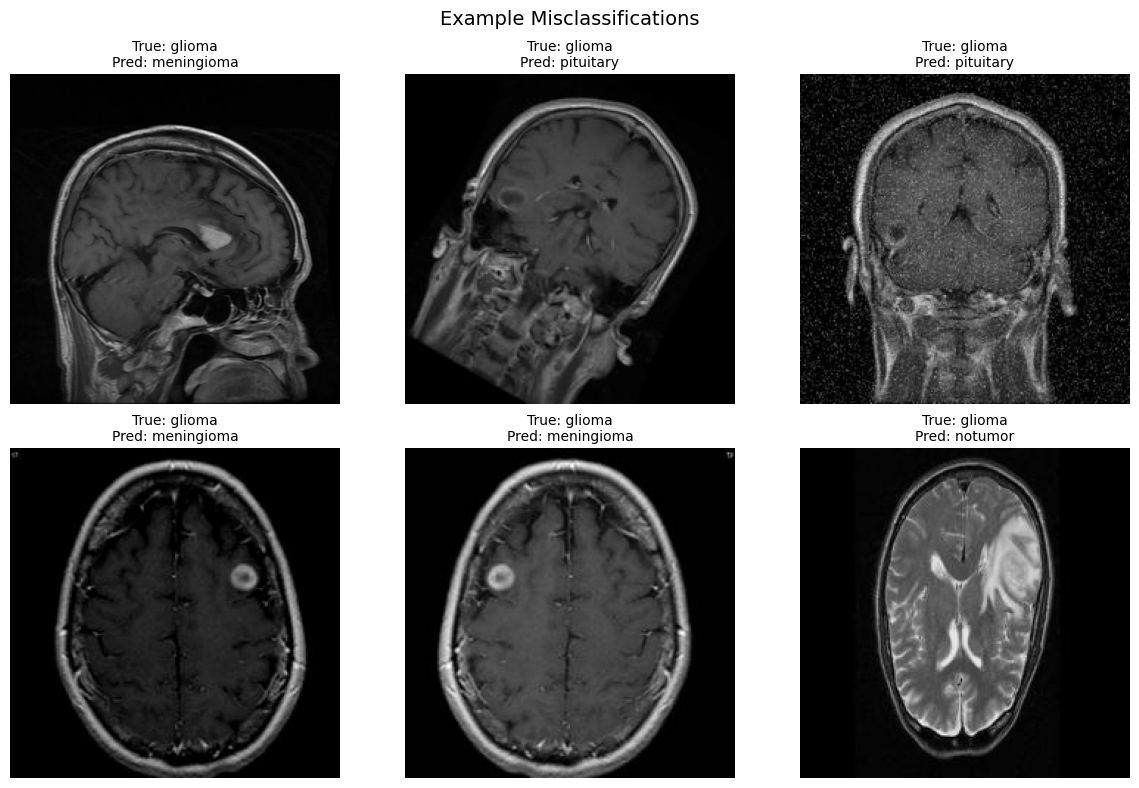

In [37]:
num_errors_to_show = min(6, len(error_df))

if num_errors_to_show > 0:
    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    axes = axes.flatten()

    for idx in range(num_errors_to_show):
        row = error_df.iloc[idx]
        image = Image.open(row["Image Path"]).convert("RGB")

        axes[idx].imshow(image)
        axes[idx].axis("off")
        axes[idx].set_title(
            f"True: {row['True Label']}\nPred: {row['Predicted Label']}",
            fontsize=10,
        )

    for idx in range(num_errors_to_show, len(axes)):
        axes[idx].axis("off")

    plt.suptitle("Example Misclassifications", fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print("No misclassified examples to display.")


## 18. Possible Improvements

# 18. Possible Improvements

This notebook provides a strong educational baseline. Several improvements could be explored:

## Compare EfficientNet Variants

Run the B1, B2, and B3 labs under the same train/validation/test split and compare accuracy, precision, recall, F1 score, training time, and memory use.

## More Data

Larger and more diverse datasets usually improve generalization. Data from different scanners, hospitals, and patient groups can help reduce dataset bias.

## Better Augmentation

Augmentations can be tuned more carefully. Medical augmentations should be realistic and should not create anatomically impossible images.

## Learning Rate Scheduling

A scheduler such as `ReduceLROnPlateau` or cosine annealing may improve fine-tuning after the model reaches a plateau.

## Class Imbalance Handling

If a class performs poorly, weighted loss functions, balanced sampling, or targeted data collection may help.

## Explainability

Grad-CAM or similar techniques can help inspect which image regions influence predictions, but visual explanations must still be interpreted carefully.

## 19. Real-World Deployment

# 19. Real-World Deployment

Deploying a medical image classifier is much more complex than training a notebook model.

## Hospital Workflow

A deployed model would need to fit into existing radiology workflows. It might prioritize scans, flag suspicious images, or provide decision support inside a clinical review system.

## Edge Deployment

Some hospitals may need models to run locally for privacy, speed, or connectivity reasons. EfficientNet-B3 may offer stronger performance, but it is less suitable for low-resource edge deployment than B1 or B2 unless latency and memory are acceptable.

## Ethical Concerns

Important ethical concerns include:

- Patient privacy.
- Dataset bias.
- Unequal performance across populations.
- Explainability and uncertainty.
- Accountability for clinical decisions.

## Human-in-the-Loop Diagnosis

Medical AI should be used with clinician oversight. A model prediction should be treated as supportive information, not as a final diagnosis.

## 20. Final Conclusion

# 20. Final Conclusion

In this guided lab, we built a complete PyTorch workflow for brain tumor MRI classification using data augmentation and EfficientNet-B3 transfer learning.

We started by understanding the problem and dataset. We counted images, inspected class balance, loaded images using `ImageFolder`, and visualized examples from each class.

We then applied preprocessing and augmentation, selected EfficientNet-B3 for transfer learning, replaced its classifier for four classes, and trained the model using Cross Entropy Loss and the Adam optimizer.

After training, we evaluated the best saved model using accuracy, precision, recall, F1 score, a classification report, and a confusion matrix. We also plotted training curves, created a single-image prediction function, and discussed error analysis.

Future work could include comparing EfficientNet-B1, B2, and B3 results, larger datasets, tuned augmentation, learning rate scheduling, class imbalance strategies, explainability methods, and careful clinical validation.

This project demonstrates the technical foundation of medical image classification while emphasizing that real-world medical AI must be validated, monitored, and used with human clinical judgment.